In [ ]:
import timm
import torch
import urllib
from PIL import Image
import sys
from pathlib import Path
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [11]:
from tokenfool.attacks.att import ATT
from tokenfool.adapters.vision_transformer import VisionTransformerClassifier

Fetch imagenet class labels

In [12]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

Initialize ViT model

In [13]:
vit = timm.create_model('vit_small_patch16_224.augreg_in1k', pretrained=True).to(device).eval()

data_config = timm.data.resolve_model_data_config(vit)
transforms = timm.data.create_transform(**data_config, is_training=False)
mean = data_config["mean"]
std = data_config["std"]

Initial image and prediction

Predicted class: 7 (cock)


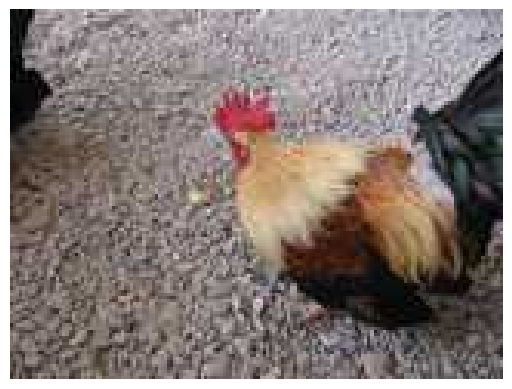

In [15]:
image_path = PROJECT_ROOT / "examples" /"test_data" / "ILSVRC2012_val_00003606.JPEG"
raw_image = Image.open(image_path).convert("RGB")
plt.imshow(raw_image)
plt.axis("off")

img = transforms(raw_image).unsqueeze(0).to(device)

with torch.no_grad():
    pred = vit(img)
pred_class = pred.argmax(dim=1).item()

print(f"Predicted class: {pred_class} ({imagenet_classes[pred_class]})")

Attack - default parameters

In [16]:
# wrap model in adapter
tokenfool_model = VisionTransformerClassifier(vit)

x_adv = ATT(
    model=tokenfool_model,
    x=img,
    mu=mean,
    std=std,
    epsilon=16/255,
    iters=10,
    patch_out=True,
    targeted=False,
    progress=True,
)

Adaptive Token Tuning (ATT):   0%|          | 0/10 [00:00<?, ?it/s]

Attacked image and prediction

Adversarial class: 633 (loupe)
Attack success: True


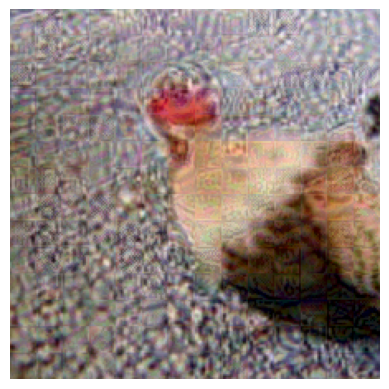

In [17]:
img_adv = x_adv[0].detach().cpu()
img_adv = img_adv * torch.tensor(std).view(3,1,1)
img_adv = img_adv + torch.tensor(mean).view(3,1,1)
plt.imshow(img_adv.permute(1,2,0).clamp(0,1))
plt.axis("off")

with torch.no_grad():
    pred_adv = vit(x_adv)
pred_adv_class = pred_adv.argmax(dim=1).item()

print(f"Adversarial class: {pred_adv_class} ({imagenet_classes[pred_adv_class]})")
print("Attack success:", pred_adv_class != pred_class)